In [1]:
#Importing dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

In [2]:
#Preloading data for analysis
housing = pd.read_csv("Bengaluru_House_Data.csv")
housing.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [4]:
# Finding null values in the dataset
housing.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [5]:
# Copying the dataset for cleaning and preprocessing
housing_clean = housing.copy()

In [6]:
#Deleting all the rows with fewer than 7 non-null values
housing_clean.dropna(axis=0, thresh = 7, inplace = True)

In [7]:
housing_clean.isnull().sum()

area_type          0
availability       0
location           1
size               0
society         5499
total_sqft         0
bath              57
balcony          593
price              0
dtype: int64

In [8]:
# Finding the row with null value in the "location" column
housing_clean[pd.isnull(housing_clean["location"])]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
568,Super built-up Area,Ready To Move,NaN,3 BHK,Grare S,1600,3.0,2.0,86.0


In [9]:
# Observed that the "Society" was grare S for location with null value, so we will be finding all the rows with "Society" grare S to find the most common location for that grade and fill the null value with that location
housing_clean[housing_clean["society"] == "Grare S"]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
568,Super built-up Area,Ready To Move,NaN,3 BHK,Grare S,1600,3.0,2.0,86.0
12238,Carpet Area,Ready To Move,Anantapura,3 BHK,Grare S,1600,3.0,2.0,77.0


In [10]:
# Filling the null value in the "location" column with the most common location for "Society" grade S, which is "Anantapura"
housing_clean["location"] =  housing_clean["location"].replace(to_replace = np.nan, value = "Anantapura")

In [11]:
# Finding the unique values in the "size" column to find the most common size for filling the null value in that column, but observed that the size was not in consistent format
housing_clean["size"].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [12]:
# Creating a new column "bhk" to store the number of bedrooms in the house, which is the first part of the "size" column before the space
housing_clean["bhk"] = housing_clean["size"].apply(lambda x: int(x.split(" ")[0]))

In [13]:
# Finding the row with null value in the "bath" column
housing_clean[pd.isnull(housing_clean["bath"])]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk
56,Built-up Area,20-Feb,Devanahalli,4 Bedroom,BrereAt,3010 - 3410,NaN,NaN,192.000,4
81,Built-up Area,18-Oct,Hennur Road,4 Bedroom,Gollela,2957 - 3450,NaN,NaN,224.500,4
224,Super built-up Area,19-Dec,Devanahalli,3 BHK,Jurdsig,1520 - 1740,NaN,NaN,74.820,3
344,Super built-up Area,21-Dec,Kanakpura Road,1 BHK,PrarePa,525,NaN,NaN,21.530,1
669,Super built-up Area,18-Dec,JP Nagar,5 BHK,Pehtsa,4400 - 6640,NaN,NaN,375.000,5
702,Super built-up Area,18-Dec,JP Nagar,5 BHK,Pehtsa,4400 - 6800,NaN,NaN,548.500,5
801,Super built-up Area,18-Dec,JP Nagar,4 BHK,Pehtsa,4000 - 5249,NaN,NaN,453.000,4
941,Super built-up Area,Ready To Move,Whitefield,4 Bedroom,PrOakSi,3606 - 5091,NaN,NaN,304.000,4
1264,Built-up Area,18-May,Hennur,3 Bedroom,Asoilul,2264,NaN,NaN,155.000,3
1267,Super built-up Area,18-Jun,Yelahanka,3 BHK,Shalkri,1440 - 1884,NaN,NaN,67.980,3


In [14]:
def IsFloat(x):
    try:
        float(x)
    except:
        return False
    return True

housing_clean[~housing_clean["total_sqft"].apply(IsFloat)]
# We can see that there are some values in the "total_sqft" column which are not in consistent metrics, so we will be converting them to consistent metrics.

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk
30,Super built-up Area,19-Dec,Yelahanka,4 BHK,LedorSa,2100 - 2850,4.0,0.0,186.000,4
56,Built-up Area,20-Feb,Devanahalli,4 Bedroom,BrereAt,3010 - 3410,NaN,NaN,192.000,4
81,Built-up Area,18-Oct,Hennur Road,4 Bedroom,Gollela,2957 - 3450,NaN,NaN,224.500,4
122,Super built-up Area,18-Mar,Hebbal,4 BHK,SNontle,3067 - 8156,4.0,0.0,477.000,4
137,Super built-up Area,19-Mar,8th Phase JP Nagar,2 BHK,Vaarech,1042 - 1105,2.0,0.0,54.005,2
...,...,...,...,...,...,...,...,...,...,...
12990,Super built-up Area,18-May,Talaghattapura,3 BHK,Sodgere,1804 - 2273,3.0,0.0,122.000,3
13059,Super built-up Area,Ready To Move,Harlur,2 BHK,Shodsir,1200 - 1470,2.0,0.0,72.760,2
13240,Super built-up Area,Ready To Move,Devanahalli,1 BHK,Pardsri,1020 - 1130,NaN,NaN,52.570,1
13265,Super built-up Area,20-Sep,Hoodi,2 BHK,Ranuetz,1133 - 1384,2.0,0.0,59.135,2


In [15]:
# Converting the values in the "total_sqft" column to consistent metrics by creating a function to convert the values to square feet and applying it to the column
def IsFloat(x):
    try:
        float(x)
    except:
        return False
    return True

metrics = []

def ConvertToSqFt(x, metric):
    if metric == "Acres":
        return x * 43560
    elif metric == "Cents":
        return x * 435.6
    elif metric == "Grounds":
        return x * 2400
    elif metric == "Guntha":
        return x * 1088.98
    elif metric == "Perch":
        return x * 272.25
    elif metric == "Sq. Meter":
        return x * 10.7639
    elif metric == "Sq. Yards":
        return x * 9
    else:
        return np.nan

def ExtractTotalSqft(x):
    try:
        values = x.split("-")
        return np.mean(list(map(float, values)))
    except:
        if x == np.nan:
            return np.nan
        else:
            for intIndex in range(len(x)-1, -1, -1):
                if IsFloat(x[0:intIndex]):
                    return ConvertToSqFt(float(x[0:intIndex]), x[intIndex:])

In [16]:
housing_clean["sqft"] = housing_clean["total_sqft"].apply(ExtractTotalSqft)

In [17]:
housing_clean["sqft"].describe()

count    1.330400e+04
mean     1.911209e+03
std      1.728725e+04
min      1.000000e+00
25%      1.100000e+03
50%      1.276000e+03
75%      1.680000e+03
max      1.306800e+06
Name: sqft, dtype: float64

In [18]:
housing_clean.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,bhk,sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,2,1056.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,4,2600.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00,3,1440.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,3,1521.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00,2,1200.0


In [19]:
housing_clean.isnull().sum()

area_type          0
availability       0
location           0
size               0
society         5499
total_sqft         0
bath              57
balcony          593
price              0
bhk                0
sqft               0
dtype: int64

In [20]:
# Filling na values in the "bath" column with the most common number of bathrooms for that number of bedrooms, which is the most common value in the "bath" column for that number of bedrooms
def FillBathrooms(bhk_groupby_bathroom, row):
    if pd.isnull(row["bath"]):
        return int(bhk_groupby_bathroom[row["bhk"]].index[0]) 
    else:
        return int(row["bath"])

bhk_groupby_bathroom = housing_clean.groupby("bhk")["bath"].value_counts()
housing_clean["bath"] = housing_clean.apply(lambda row: FillBathrooms(bhk_groupby_bathroom, row), axis=1)

In [21]:
# Filling na values in the "balcony" column with the most common number of balconies for that number of bedrooms, which is the most common value in the "balcony" column for that number of bedrooms
def FillBalcony(bhk_groupby_balcony, row):
    if pd.isnull(row["balcony"]):
        try:
            return int(bhk_groupby_balcony[row["bhk"]].index[0])
        except KeyError:
            return 0
    else:
        return int(row["balcony"])

bhk_groupby_balcony = housing_clean.groupby("bhk")["balcony"].value_counts()

housing_clean["balcony"] = housing_clean.apply(
    lambda row: FillBalcony(bhk_groupby_balcony, row),
    axis=1
)

In [22]:
housing_clean.drop(["society", "size", "total_sqft"], inplace = True, axis=1)

In [23]:
housing_clean.isnull().sum()

area_type       0
availability    0
location        0
bath            0
balcony         0
price           0
bhk             0
sqft            0
dtype: int64

In [24]:
housing_clean.head()

,area_type,availability,location,bath,balcony,price,bhk,sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2,1,39.07,2,1056.0
1,Plot Area,Ready To Move,Chikka Tirupathi,5,3,120.00,4,2600.0
2,Built-up Area,Ready To Move,Uttarahalli,2,3,62.00,3,1440.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,1,95.00,3,1521.0
4,Super built-up Area,Ready To Move,Kothanur,2,1,51.00,2,1200.0


In [25]:
# Feature engineering for the "availability" column to convert the values to consistent format by creating a function to relabel the values and applying it to the column
def RelabelAvailability(x):
    values = x.split("-")
    try:
        if len(values) > 1:
            return "Soon to be Vacated"
        else:
            return x
    except:
            return ""
housing_clean["availability"] = housing_clean["availability"].apply(RelabelAvailability)

In [26]:
# Finding the unique values in the "location" column to find the most common location for filling the null value in that column, but observed that there are many unique values in that column, so we will be grouping the locations with less than 10 occurrences as "Other"
housing_clean["location"] = housing_clean["location"].apply(lambda x: x.strip())
unique_location_count = housing_clean.groupby("location")["location"].agg("count").sort_values(ascending = False)
unique_location_count_10 = unique_location_count[unique_location_count <= 10]
housing_clean["location"] = housing_clean["location"].apply(lambda x : "Other" if x in unique_location_count_10 else x)

In [27]:
# Creating a new column "price_per_sqft" to store the price per square feet of the house by dividing the price by the total square feet of the house
housing_clean["price_per_sqft"] = housing_clean["price"] * 100000 / housing_clean["sqft"]

In [28]:
# Creating a new column "sqft_per_bhk" to store the square feet per bedroom of the house by dividing the total square feet of the house by the number of bedrooms in the house
housing_clean["sqft_per_bhk"] = housing_clean["sqft"] / housing_clean["bhk"]

In [29]:
# Removing the outliers in the "price_per_sqft" column by removing the rows with price per square feet greater than the 99th percentile of the price per square feet
housing_clean = housing_clean[housing_clean['price_per_sqft'] < housing_clean['price_per_sqft'].quantile(0.99)]

In [30]:
# Checking the outliers in the "sqft_per_bhk" column by removing the rows with square feet per bedroom less than 300 square feet per bedroom, which is a reasonable assumption for a house
housing_clean[housing_clean["sqft_per_bhk"] < 300].count()

area_type         709
availability      709
location          709
bath              709
balcony           709
price             709
bhk               709
sqft              709
price_per_sqft    709
sqft_per_bhk      709
dtype: int64

In [31]:
# Checking the outliers in the "sqft_per_bhk" column by removing the rows with square feet per bedroom greater than 1500 square feet per bedroom, which is a reasonable assumption for a house
housing_clean[housing_clean["sqft_per_bhk"] > 1500].count()

area_type         95
availability      95
location          95
bath              95
balcony           95
price             95
bhk               95
sqft              95
price_per_sqft    95
sqft_per_bhk      95
dtype: int64

In [32]:
#Removing the outliers in the "sqft_per_bhk" column by removing the rows with square feet per bedroom less than 300 square feet per bedroom and greater than 1200 square feet per bedroom, which is a reasonable assumption for a house
housing_clean['sqft_per_bhk'] = housing_clean['sqft'] / housing_clean['bhk']
housing_clean = housing_clean[~(housing_clean['sqft_per_bhk'] < 300)]
housing_clean = housing_clean[~(housing_clean['sqft_per_bhk'] > 1200)]

In [33]:
# Removing the outliers in the "sqft" column by removing the rows with square feet greater than 6000 square feet, which is a reasonable assumption for a house
housing_clean = housing_clean[~(housing_clean["sqft"] > 6000)]

In [34]:
housing_clean.sort_values(["price"], ascending=False)

,area_type,availability,location,bath,balcony,price,bhk,sqft,price_per_sqft,sqft_per_bhk
1873,Plot Area,Ready To Move,Kasavanhalli,7,2,1200.0,5,5800.0000,20689.655172,1160.000000
6190,Super built-up Area,Soon to be Vacated,Other,6,1,1102.0,4,4750.0000,23200.000000,1187.500000
13086,Super built-up Area,Ready To Move,Other,7,2,988.0,5,5665.8400,17437.837990,1133.168000
7447,Super built-up Area,Ready To Move,Other,5,2,980.0,5,4900.0000,20000.000000,980.000000
6274,Plot Area,Soon to be Vacated,Other,5,3,972.0,7,5400.0000,18000.000000,771.428571
...,...,...,...,...,...,...,...,...,...,...
1471,Built-up Area,Soon to be Vacated,Kengeri,1,1,10.0,1,340.0000,2941.176471,340.000000
4113,Super built-up Area,Soon to be Vacated,BTM Layout,3,2,10.0,3,1797.5713,556.306167,599.190433
5410,Super built-up Area,Ready To Move,Attibele,1,1,10.0,1,400.0000,2500.000000,400.000000
11091,Built-up Area,Ready To Move,Attibele,1,1,10.0,1,410.0000,2439.024390,410.000000


In [35]:
# Removing the outliers in the "price_per_sqft" column by removing the rows with price per square feet greater than 20000, which is a reasonable assumption for a house
housing_clean = housing_clean[~(housing_clean["price_per_sqft"] > 20000)]

In [36]:
# Remove unrealistic house listings based on BHK and price per sqft.
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }
        # Mark houses for removal if their price per sqft is lower than
        # the average price per sqft of houses with one less BHK.
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values) 
    return df.drop(exclude_indices,axis='index')

housing_clean = remove_bhk_outliers(housing_clean)

In [37]:
housing_clean = housing_clean[housing_clean.bath < housing_clean.bhk+2]
housing_clean.shape

(8498, 10)

In [38]:
#Finding the correlation of the features with the target variable "price" to find the most important features for the model
housing_clean.drop(columns = ["area_type", "availability", "location"]).corr()["price"].sort_values(ascending=False)


price             1.000000
sqft              0.820807
price_per_sqft    0.782903
bath              0.650978
bhk               0.634278
sqft_per_bhk      0.470972
balcony           0.214122
Name: price, dtype: float64

In [39]:
housing_clean.drop(["price_per_sqft", "sqft_per_bhk", "balcony"], axis = 1, inplace = True)

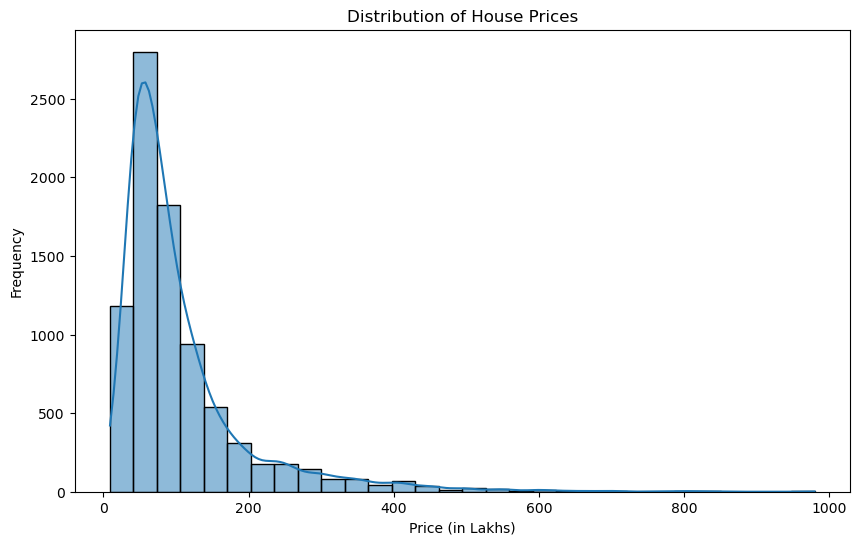

In [40]:
# Visualizing the distribution of the target variable "price" to check for skewness and outliers
plt.figure(figsize=(10, 6))
sns.histplot(housing_clean['price'], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price (in Lakhs)")
plt.ylabel("Frequency")
plt.show()

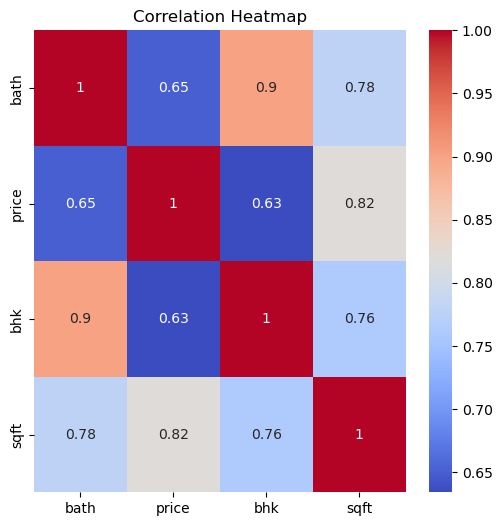

In [41]:
# Visualizing the correlation between the features and the target variable "price" using a heatmap to find the most important features for the model
plt.figure(figsize=(6, 6))
sns.heatmap(housing_clean.drop(columns = ["area_type", "availability", "location"]).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [42]:
# Saving the cleaned and preprocessed dataset to a new CSV file for future use
housing_clean.to_csv("Cleaned_data.csv")

In [43]:
# Splitting the dataset into training and testing sets for model building and evaluation
from sklearn.model_selection import train_test_split
X = housing_clean.drop(columns = "price")
y = housing_clean['price']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2) 

In [44]:
#Importing models and evaluation metrics for model building and evaluation
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [45]:
# Creating a column transformer to apply one hot encoding to the categorical features
column_trans = make_column_transformer((OneHotEncoder(sparse_output=False), ["area_type", "availability", "location"]), remainder='passthrough')

In [46]:
# Creating pipelines for different regression models to apply the column transformer and the model in a single step
scaler = StandardScaler()
lr = LinearRegression()
la = Lasso()
ri = Ridge()
xgb = XGBRegressor()
rfr = RandomForestRegressor()
ada = AdaBoostRegressor()
gbr = GradientBoostingRegressor()
dt = DecisionTreeRegressor()

In [47]:
# Creating a dictionary to store the models for easy access and evaluation
Regressors = {
    'Linear Regression' : lr,
    'Lasso' : la, 
    'Ridge': ri,
    'XGBRegressor': xgb,
    'RandomForestRegressor': rfr, 
    'AdaBoostRegressor': ada, 
    'gradient Boost Regressor': gbr, 
    'Decision Tree Regressor': dt
}

In [48]:
# Evaluating the models using R2 score and Mean Squared Error to find the best model for the dataset
for name,model in Regressors.items():
    pipe = make_pipeline(column_trans, scaler,model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print("For ",name)
    print("R2 Score ",r2_score(y_test,y_pred))
    print("MSE ",mean_squared_error(y_test,y_pred))
    print("==================================================")

For  Linear Regression
R2 Score  0.762280437800853
MSE  2158.153364286466
For  Lasso
R2 Score  0.7505199781103946
MSE  2264.9215049128384
For  Ridge
R2 Score  0.7622576200183879
MSE  2158.3605170909595
For  XGBRegressor
R2 Score  0.8132355429044069
MSE  1695.5539446615883
For  RandomForestRegressor
R2 Score  0.8041342142921447
MSE  1778.180981251768
For  AdaBoostRegressor
R2 Score  0.6366971841578914
MSE  3298.2695534646505
For  gradient Boost Regressor
R2 Score  0.7939222788698233
MSE  1870.8907380074872
For  Decision Tree Regressor
R2 Score  0.6538468118217375
MSE  3142.5754814387915


In [49]:
# Creating a pipeline for the best model to apply the column transformer and the model in a single step and fitting the model to the training data
pipe = make_pipeline(column_trans, scaler,xgb)
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['area_type','availability','location','bath','bhk','sqft']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of column

In [50]:
housing_clean.head(1)

,area_type,availability,location,bath,price,bhk,sqft
0,Super built-up Area,Soon to be Vacated,Electronic City Phase II,2,39.07,2,1056.0


In [51]:
# Saving the best model to a file using pickle for future use in making predictions on new data
import pickle
pickle.dump(pipe,open("Model.pkl",'wb'))